Features shape: (150, 4)
Labels shape: (150,)
k=1  accuracy=0.9417
k=2  accuracy=0.9333
k=3  accuracy=0.9500
k=4  accuracy=0.9417
k=5  accuracy=0.9250
k=6  accuracy=0.9333
k=7  accuracy=0.9417
k=8  accuracy=0.9417
k=9  accuracy=0.9417

Best k: 3
Model trained successfully!

Accuracy: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



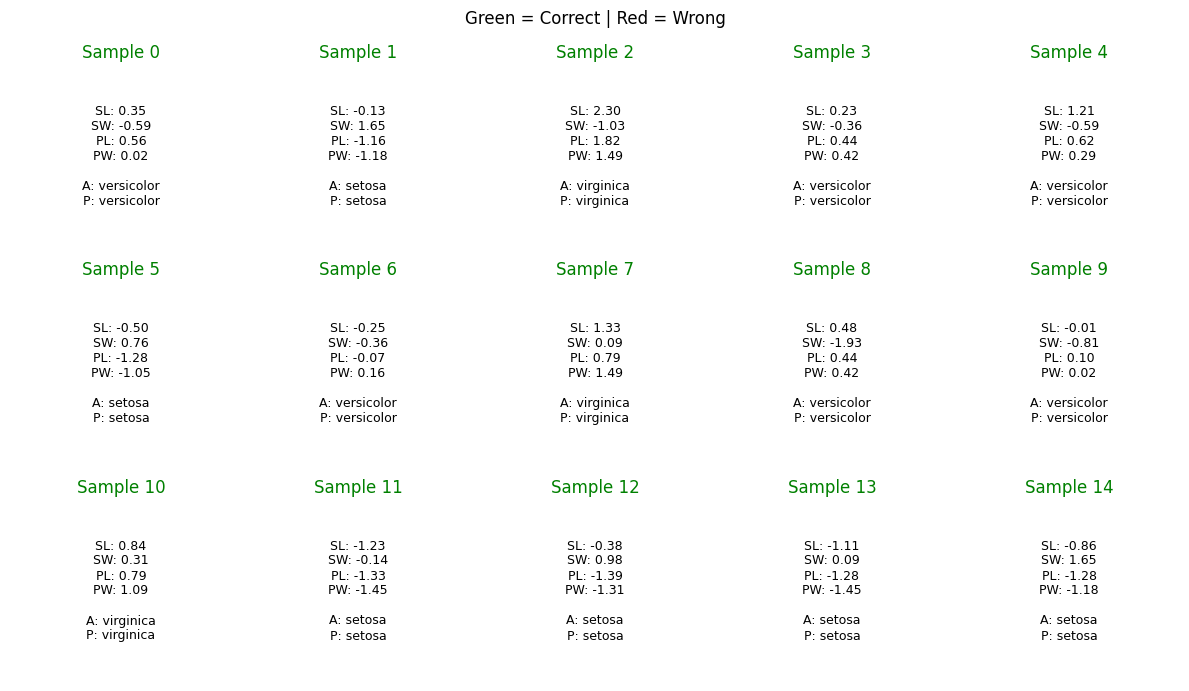

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np


iris = load_iris()
X = iris.data
y = iris.target

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


k_values = range(1, 10)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5)
    cv_scores.append(scores.mean())
    print(f"k={k}  accuracy={scores.mean():.4f}")

best_k = k_values[np.argmax(cv_scores)]
print(f"\nBest k: {best_k}")


knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
print("Model trained successfully!")


y_pred = knn.predict(X_test)


print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))



fig, axes = plt.subplots(3, 5, figsize=(12, 7))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= len(X_test):
        break

    color = 'green' if y_pred[i] == y_test[i] else 'red'

    text = (
        f"SL: {X_test[i][0]:.2f}\n"
        f"SW: {X_test[i][1]:.2f}\n"
        f"PL: {X_test[i][2]:.2f}\n"
        f"PW: {X_test[i][3]:.2f}\n\n"
        f"A: {iris.target_names[y_test[i]]}\n"
        f"P: {iris.target_names[y_pred[i]]}"
    )

    ax.text(0.5, 0.5, text, ha='center', va='center', fontsize=9)
    ax.set_title(f"Sample {i}", color=color)
    ax.axis('off')

plt.suptitle("Green = Correct | Red = Wrong")
plt.tight_layout()
plt.show()